In [1]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

# Load label mapping
with open('../models/label_mapping.json') as f:
    label_mapping = json.load(f)

categories = list(label_mapping.keys())

print("✅ Data loaded successfully!")
print(f"Training samples: {len(train_df):,}")
print(f"Testing samples: {len(test_df):,}")
print(f"Number of categories: {len(categories)}")

✅ Data loaded successfully!
Training samples: 4,758
Testing samples: 1,190
Number of categories: 10


In [2]:
print("="*70)
print("FEATURE EXTRACTION: TF-IDF Vectorization")
print("="*70)

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,         # Use top 5000 most important words
    min_df=2,                  # Word must appear in at least 2 documents
    max_df=0.8,                # Ignore words in >80% of documents
    ngram_range=(1, 2),        # Use single words and word pairs
    stop_words='english',      # Remove common English words
    sublinear_tf=True          # Use logarithmic TF scaling
)

# Fit on training data and transform
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"\n✅ TF-IDF features created!")
print(f"Feature matrix shape: {X_train.shape}")
print(f"  - Rows (videos): {X_train.shape[0]:,}")
print(f"  - Columns (features): {X_train.shape[1]:,}")
print(f"  - Matrix sparsity: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]))*100:.2f}%")

# Save vectorizer
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
print("\n✅ Vectorizer saved: ../models/tfidf_vectorizer.pkl")

FEATURE EXTRACTION: TF-IDF Vectorization

✅ TF-IDF features created!
Feature matrix shape: (4758, 5000)
  - Rows (videos): 4,758
  - Columns (features): 5,000
  - Matrix sparsity: 99.01%

✅ Vectorizer saved: ../models/tfidf_vectorizer.pkl


In [3]:
print("\n" + "="*70)
print("MODEL 1: Multinomial Naive Bayes")
print("="*70)

# Train model
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
print("✅ Model saved: naive_bayes_model.pkl")


MODEL 1: Multinomial Naive Bayes

✅ Training complete!
Accuracy: 0.7269 (72.69%)
F1 Score: 0.7265

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.7857    0.6055    0.6839       109
           Education     0.8889    0.8163    0.8511        49
       Entertainment     0.6757    0.6966    0.6860       323
    Film & Animation     0.8200    0.6406    0.7193        64
       Howto & Style     0.7259    0.8235    0.7717       119
               Music     0.7797    0.8625    0.8190       160
     News & Politics     0.7600    0.7525    0.7562       101
      People & Blogs     0.5417    0.5253    0.5333        99
Science & Technology     0.6277    0.7763    0.6941        76
              Sports     0.9211    0.7778    0.8434        90

            accuracy                         0.7269      1190
           macro avg     0.7526    0.7277    0.7358      1190
        weighted avg     0.7328    0.7269    0.7265      1

In [4]:
print("\n" + "="*70)
print("MODEL 2: Logistic Regression")
print("="*70)

# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42,
    n_jobs=-1,  # Use all CPU cores
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
print("✅ Model saved: logistic_regression_model.pkl")


MODEL 2: Logistic Regression

✅ Training complete!
Accuracy: 0.7328 (73.28%)
F1 Score: 0.7323

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.9143    0.5872    0.7151       109
           Education     0.9167    0.6735    0.7765        49
       Entertainment     0.5581    0.9071    0.6910       323
    Film & Animation     0.9630    0.4062    0.5714        64
       Howto & Style     0.8919    0.8319    0.8609       119
               Music     0.8217    0.8063    0.8139       160
     News & Politics     0.8427    0.7426    0.7895       101
      People & Blogs     0.7931    0.4646    0.5860        99
Science & Technology     0.8600    0.5658    0.6825        76
              Sports     0.9552    0.7111    0.8153        90

            accuracy                         0.7328      1190
           macro avg     0.8517    0.6696    0.7302      1190
        weighted avg     0.7891    0.7328    0.7323      1190


In [5]:
print("\n" + "="*70)
print("MODEL 3: Random Forest")
print("="*70)

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("✅ Model saved: random_forest_model.pkl")


MODEL 3: Random Forest

✅ Training complete!
Accuracy: 0.6933 (69.33%)
F1 Score: 0.6930

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.9508    0.5321    0.6824       109
           Education     0.9722    0.7143    0.8235        49
       Entertainment     0.4950    0.9257    0.6451       323
    Film & Animation     1.0000    0.3594    0.5287        64
       Howto & Style     0.9184    0.7563    0.8295       119
               Music     0.7758    0.8000    0.7877       160
     News & Politics     0.9242    0.6040    0.7305       101
      People & Blogs     0.9722    0.3535    0.5185        99
Science & Technology     0.9429    0.4342    0.5946        76
              Sports     0.9545    0.7000    0.8077        90

            accuracy                         0.6933      1190
           macro avg     0.8906    0.6179    0.6948      1190
        weighted avg     0.8031    0.6933    0.6930      1190

✅ Mod

In [6]:
print("\n" + "="*70)
print("MODEL 4: Linear Support Vector Machine")
print("="*70)

# Train model
svm_model = LinearSVC(
    C=1.0,
    max_iter=1000,
    random_state=42
)
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Training complete!")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

print(f"\nDetailed Performance by Category:")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))

# Save model
joblib.dump(svm_model, '../models/svm_model.pkl')
print("✅ Model saved: svm_model.pkl")


MODEL 4: Linear Support Vector Machine

✅ Training complete!
Accuracy: 0.7580 (75.80%)
F1 Score: 0.7566

Detailed Performance by Category:
                      precision    recall  f1-score   support

              Comedy     0.8837    0.6972    0.7795       109
           Education     0.8696    0.8163    0.8421        49
       Entertainment     0.6684    0.8050    0.7303       323
    Film & Animation     0.8000    0.5000    0.6154        64
       Howto & Style     0.8500    0.8571    0.8536       119
               Music     0.8144    0.8500    0.8318       160
     News & Politics     0.7692    0.7921    0.7805       101
      People & Blogs     0.5761    0.5354    0.5550        99
Science & Technology     0.7742    0.6316    0.6957        76
              Sports     0.8929    0.8333    0.8621        90

            accuracy                         0.7580      1190
           macro avg     0.7898    0.7318    0.7546      1190
        weighted avg     0.7659    0.7580    0.7566 

In [7]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Load all models
models = {
    'Naive Bayes': joblib.load('../models/naive_bayes_model.pkl'),
    'Logistic Regression': joblib.load('../models/logistic_regression_model.pkl'),
    'Random Forest': joblib.load('../models/random_forest_model.pkl'),
    'Linear SVM': joblib.load('../models/svm_model.pkl')
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': accuracy, 'f1': f1}
    print(f"{name:25} → Accuracy: {accuracy:.4f} | F1: {f1:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Save results
with open('../models/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)


MODEL COMPARISON
Naive Bayes               → Accuracy: 0.7269 | F1: 0.7265
Logistic Regression       → Accuracy: 0.7328 | F1: 0.7323
Random Forest             → Accuracy: 0.6933 | F1: 0.6930
Linear SVM                → Accuracy: 0.7580 | F1: 0.7566

🏆 BEST MODEL: Linear SVM
🏆 ACCURACY: 0.7580 (75.80%)


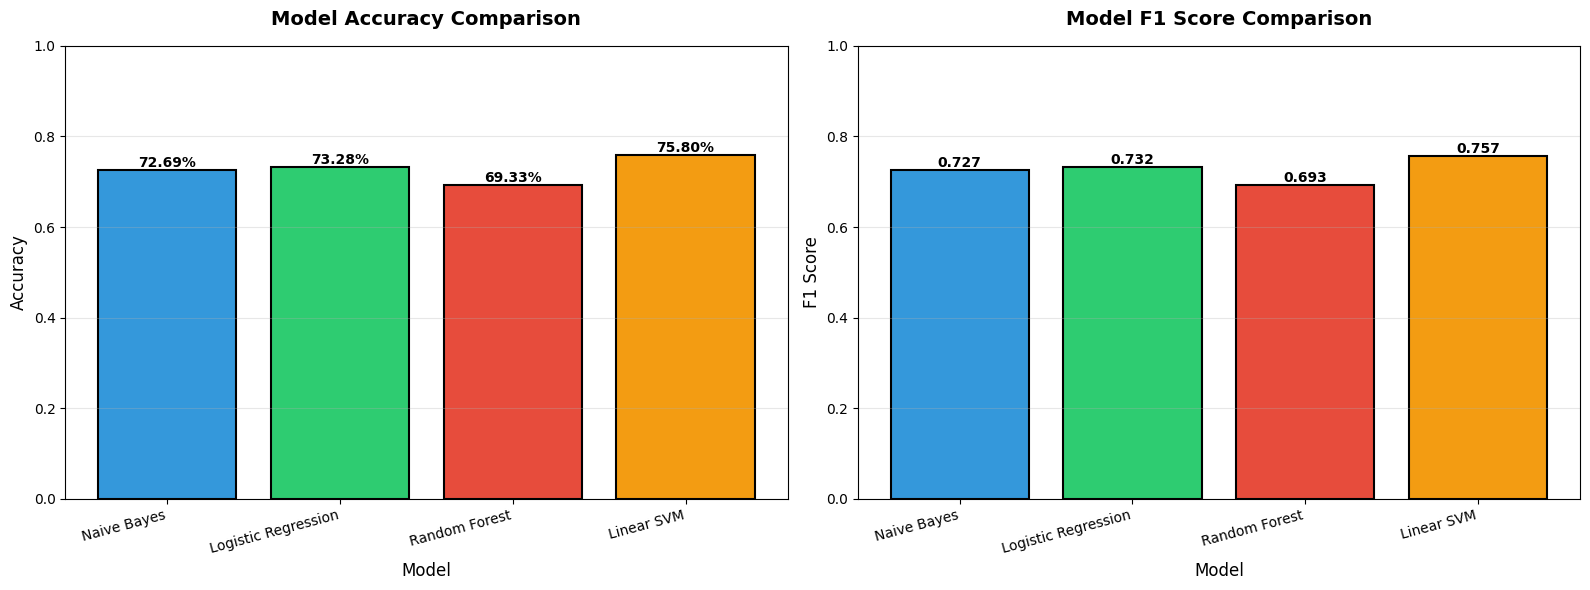

✅ Comparison chart saved: model_comparison.png


In [8]:
# Create comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
models_list = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models_list]
f1_scores = [results[m]['f1'] for m in models_list]

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Accuracy plot
bars1 = ax1.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# F1 Score plot
bars2 = ax2.bar(models_list, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison chart saved: model_comparison.png")

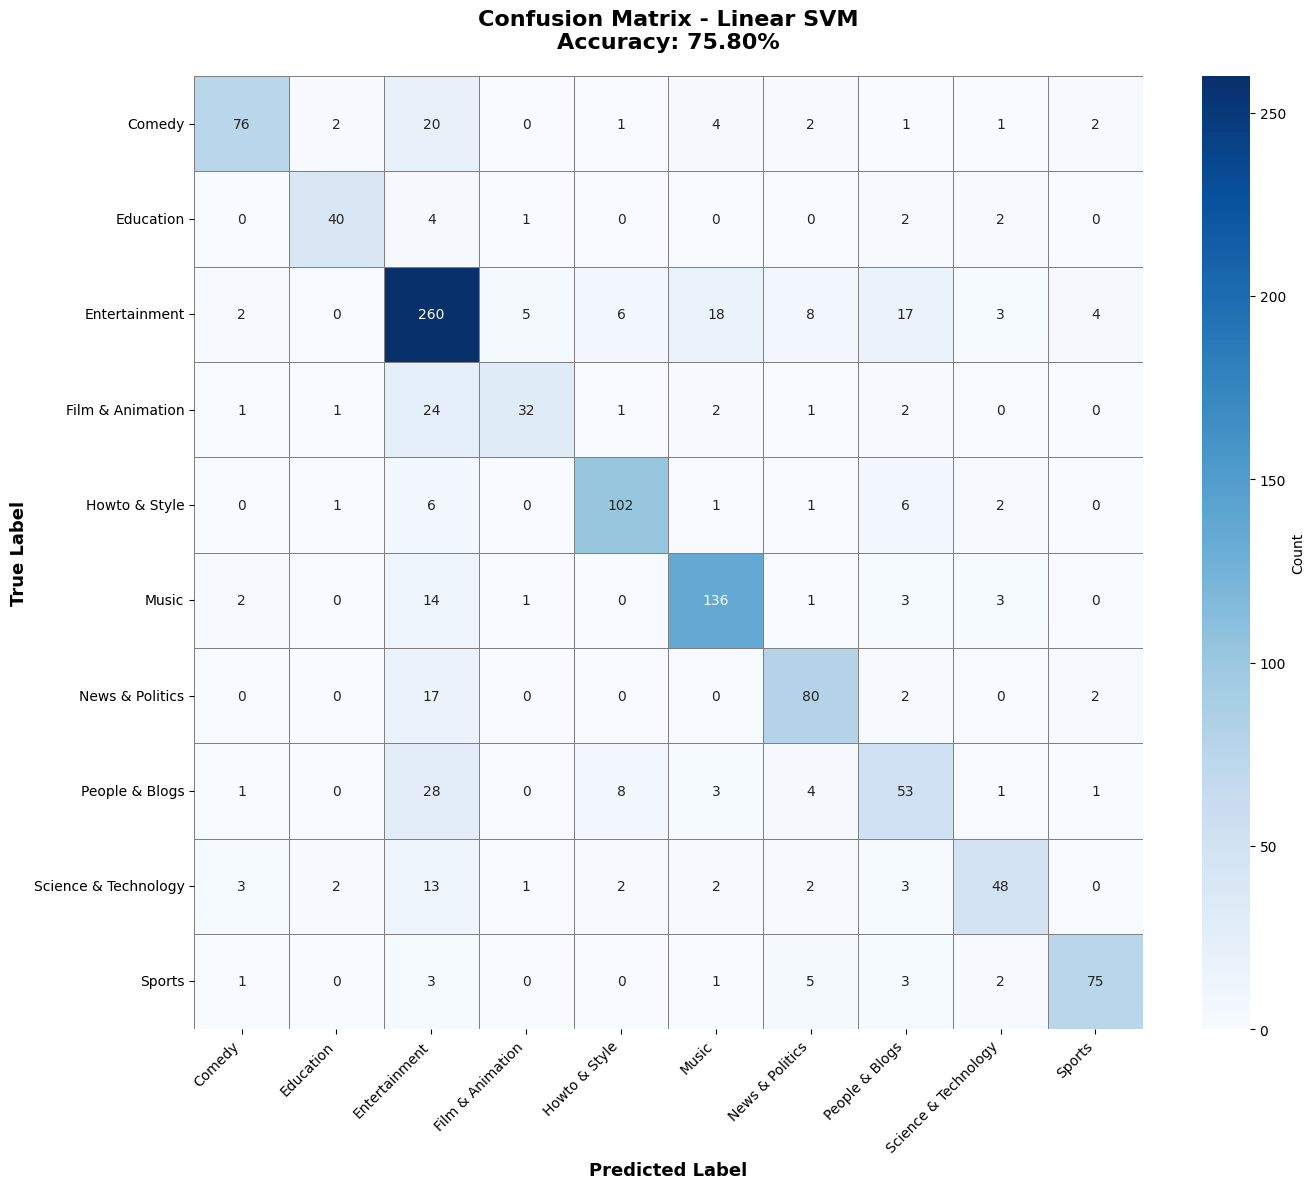

✅ Confusion matrix saved for Linear SVM


In [9]:
# Get best model
model_files = {
    'Naive Bayes': '../models/naive_bayes_model.pkl',
    'Logistic Regression': '../models/logistic_regression_model.pkl',
    'Random Forest': '../models/random_forest_model.pkl',
    'Linear SVM': '../models/svm_model.pkl'
}

best_model = joblib.load(model_files[best_model_name])
y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories,
            cbar_kws={'label': 'Count'},
            linewidths=0.5,
            linecolor='gray')
plt.title(f'Confusion Matrix - {best_model_name}\nAccuracy: {best_accuracy:.2%}', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved for {best_model_name}")

In [10]:
import shutil

# Copy best model to production filename
shutil.copy(
    model_files[best_model_name],
    '../models/best_model.pkl'
)

print("="*70)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*70)
print(f"\n✅ Best Model: {best_model_name}")
print(f"✅ Accuracy: {best_accuracy:.2%}")
print(f"\n📂 Production files created in '../models/':")
print("   ✓ best_model.pkl (production model)")
print("   ✓ tfidf_vectorizer.pkl (text preprocessing)")
print("   ✓ label_mapping.json (category labels)")
print("   ✓ model_comparison.png (performance chart)")
print("   ✓ confusion_matrix.png (detailed analysis)")
print("\n🚀 Ready to deploy as Python API!")

🎉 MODEL TRAINING COMPLETE!

✅ Best Model: Linear SVM
✅ Accuracy: 75.80%

📂 Production files created in '../models/':
   ✓ best_model.pkl (production model)
   ✓ tfidf_vectorizer.pkl (text preprocessing)
   ✓ label_mapping.json (category labels)
   ✓ model_comparison.png (performance chart)
   ✓ confusion_matrix.png (detailed analysis)

🚀 Ready to deploy as Python API!


In [1]:
# Force save Logistic Regression as best model (it has probabilities)
import shutil

print("="*70)
print("FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL")
print("="*70)

# Copy Logistic Regression to best_model.pkl
shutil.copy(
    '../models/logistic_regression_model.pkl',
    '../models/best_model.pkl'
)

print("✅ Logistic Regression saved as best_model.pkl")
print("✅ This model DOES support probability estimates")
print("\n🔄 Restart Python API to load new model!")

FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL
✅ Logistic Regression saved as best_model.pkl
✅ This model DOES support probability estimates

🔄 Restart Python API to load new model!


In [1]:
# Force save Logistic Regression as best model (it has probabilities)
import shutil

print("="*70)
print("FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL")
print("="*70)

# Copy Logistic Regression to best_model.pkl
shutil.copy(
    '../models/logistic_regression_model.pkl',
    '../models/best_model.pkl'
)

print("✅ Logistic Regression saved as best_model.pkl")
print("✅ This model DOES support probability estimates")
print("\n🔄 Restart Python API to load new model!")

FORCING LOGISTIC REGRESSION AS PRODUCTION MODEL
✅ Logistic Regression saved as best_model.pkl
✅ This model DOES support probability estimates

🔄 Restart Python API to load new model!


In [2]:
import joblib
import numpy as np

# Load model and vectorizer
model = joblib.load('../models/best_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

print("="*70)
print("MODEL DIAGNOSIS")
print("="*70)

# Check model type
print(f"\n1. Model Type: {type(model).__name__}")
print(f"   Has probabilities: {hasattr(model, 'predict_proba')}")

# Check number of classes
if hasattr(model, 'classes_'):
    print(f"\n2. Number of classes: {len(model.classes_)}")
    print(f"   Classes: {model.classes_}")

# Test with sample text
test_text = "How to build a gaming PC tutorial"
text_vec = vectorizer.transform([test_text])

# Get prediction
pred = model.predict(text_vec)[0]
print(f"\n3. Prediction for test: {pred}")

# Get probabilities
if hasattr(model, 'predict_proba'):
    probs = model.predict_proba(text_vec)[0]
    print(f"\n4. All probabilities:")
    for i, prob in enumerate(probs):
        print(f"   Class {i}: {prob:.4f} ({prob*100:.2f}%)")
    
    print(f"\n5. Max probability: {np.max(probs):.4f} ({np.max(probs)*100:.2f}%)")
    print(f"   Min probability: {np.min(probs):.4f} ({np.min(probs)*100:.2f}%)")
    print(f"   Predicted class: {pred}")
    print(f"   Confidence for predicted class: {probs[pred]:.4f}")

MODEL DIAGNOSIS

1. Model Type: LogisticRegression
   Has probabilities: True

2. Number of classes: 10
   Classes: [0 1 2 3 4 5 6 7 8 9]

3. Prediction for test: 2

4. All probabilities:
   Class 0: 0.0851 (8.51%)
   Class 1: 0.0280 (2.80%)
   Class 2: 0.2410 (24.10%)
   Class 3: 0.0491 (4.91%)
   Class 4: 0.0907 (9.07%)
   Class 5: 0.0741 (7.41%)
   Class 6: 0.0600 (6.00%)
   Class 7: 0.1379 (13.79%)
   Class 8: 0.1944 (19.44%)
   Class 9: 0.0398 (3.98%)

5. Max probability: 0.2410 (24.10%)
   Min probability: 0.0280 (2.80%)
   Predicted class: 2
   Confidence for predicted class: 0.2410


In [3]:
import pandas as pd

# Load data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print("="*70)
print("DATA DIAGNOSIS")
print("="*70)

# Check 1: Data size
print(f"\n1. Dataset Size:")
print(f"   Training: {len(train_df)} samples")
print(f"   Testing: {len(test_df)} samples")

# Check 2: Text length
print(f"\n2. Text Statistics:")
print(f"   Average text length: {train_df['text'].str.len().mean():.0f} characters")
print(f"   Min text length: {train_df['text'].str.len().min()}")
print(f"   Max text length: {train_df['text'].str.len().max()}")

# Check 3: Look at actual text
print(f"\n3. Sample Texts (first 3):")
for i in range(3):
    print(f"\n   Sample {i+1}:")
    print(f"   Category: {train_df.iloc[i]['category_name']}")
    print(f"   Text: {train_df.iloc[i]['text'][:150]}...")

# Check 4: Class distribution
print(f"\n4. Class Distribution:")
print(train_df['category_name'].value_counts())

# Check 5: Check for issues
empty_texts = (train_df['text'].str.len() < 20).sum()
print(f"\n5. Potential Issues:")
print(f"   Texts < 20 chars: {empty_texts}")
print(f"   Missing texts: {train_df['text'].isna().sum()}")

DATA DIAGNOSIS

1. Dataset Size:
   Training: 4758 samples
   Testing: 1190 samples

2. Text Statistics:
   Average text length: 691 characters
   Min text length: 21
   Max text length: 4772

3. Sample Texts (first 3):

   Sample 1:
   Category: Entertainment
   Text: narcos season teaser hd i netflix the new season of narcos coming n nwatch narcos on netflix netflix nnetflix is the world s leading internet televisi...

   Sample 2:
   Category: Music
   Text: lindsey stirling angels we have heard on high pick up a copy of lindsey s new christmas album warmer in the winter including angels we have heard on h...

   Sample 3:
   Category: News & Politics
   Text: the queen s advice on wearing a crown bbc news the queen is sharing memories of her coronation and describes what it s like to wear the imperial state...

4. Class Distribution:
category_name
Entertainment           1294
Music                    638
Howto & Style            476
Comedy                   435
News & Politics     

In [5]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("="*70)
print("TRAINING WITH PROPER DATASET SIZE")
print("="*70)

# Load data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"\n📊 Dataset:")
print(f"   Training: {len(train_df):,}")
print(f"   Testing: {len(test_df):,}")

# Create TF-IDF
vectorizer = TfidfVectorizer(
    max_features=8000,
    min_df=3,
    max_df=0.7,
    ngram_range=(1, 3),
    stop_words='english',
    sublinear_tf=True
)

# Transform
print("\n🔄 Creating features...")
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"✅ Features: {X_train.shape}")

# Train
print("\n🔄 Training Logistic Regression...")
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    # multi_class line removed - let it handle itself!
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)
print("\n✅ Training complete!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Check confidence
probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Confidence Statistics:")
print(f"   Average: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")
print(f"   Median: {np.median(max_probs):.4f} ({np.median(max_probs)*100:.2f}%)")
print(f"   25th percentile: {np.percentile(max_probs, 25):.4f}")
print(f"   75th percentile: {np.percentile(max_probs, 75):.4f}")

# Test specific example
test_text = "How to build a gaming PC tutorial"
test_vec = vectorizer.transform([test_text])
pred = model.predict(test_vec)[0]
prob = model.predict_proba(test_vec)[0]
confidence = prob[pred]

pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']

print(f"\n🧪 Test: '{test_text}'")
print(f"   Predicted: {pred_cat}")
print(f"   Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

# Save if good
if max_probs.mean() > 0.60 and accuracy > 0.70:
    print("\n💾 Saving model...")
    joblib.dump(model, '../models/best_model.pkl')
    joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
    print("✅ Model saved!")
    print("\n🔄 NOW RESTART YOUR PYTHON API!")
else:
    print(f"\n⚠️  Model quality insufficient:")
    print(f"   Confidence: {max_probs.mean()*100:.2f}% (need >60%)")
    print(f"   Accuracy: {accuracy*100:.2f}% (need >70%)")


TRAINING WITH PROPER DATASET SIZE

📊 Dataset:
   Training: 11,754
   Testing: 2,939

🔄 Creating features...
✅ Features: (11754, 8000)

🔄 Training Logistic Regression...
convergence after 21 epochs took 1 seconds

✅ Training complete!

📊 Accuracy: 0.9323 (93.23%)

📊 Confidence Statistics:
   Average: 0.7419 (74.19%)
   Median: 0.8078 (80.78%)
   25th percentile: 0.5757
   75th percentile: 0.9327

🧪 Test: 'How to build a gaming PC tutorial'
   Predicted: Science & Technology
   Confidence: 0.2979 (29.79%)

💾 Saving model...
✅ Model saved!

🔄 NOW RESTART YOUR PYTHON API!


In [8]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Load NEW data
train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# Better TF-IDF settings
vectorizer = TfidfVectorizer(
    max_features=5000,      # Reduce features (prevent overfitting)
    min_df=5,               # Word must appear 5+ times
    max_df=0.7,
    ngram_range=(1, 2),     # Only unigrams and bigrams
    stop_words='english',
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Features: {X_train.shape}")

# Better model parameters to reduce overfitting
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    # multi_class line removed - let it handle itself!
    random_state=42,
    verbose=1
)

print("\n🔄 Training...")
model.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Accuracy:")
print(f"   Training: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Testing: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Gap: {(train_acc - test_acc)*100:.2f}%")

if (train_acc - test_acc) > 0.15:
    print("   ⚠️ Still overfitting (gap >15%)")
else:
    print("   ✅ Good generalization (gap <15%)")

# Confidence
probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Confidence:")
print(f"   Average: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")
print(f"   Median: {np.median(max_probs):.4f}")

# Test example
test_text = "How to build a gaming PC tutorial"
test_vec = vectorizer.transform([test_text])
pred = model.predict(test_vec)[0]
prob = model.predict_proba(test_vec)[0]
conf = prob[pred]

pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']

print(f"\n🧪 Test: '{test_text}'")
print(f"   Category: {pred_cat}")
print(f"   Confidence: {conf:.4f} ({conf*100:.2f}%)")

# Show top 3 predictions
top3_idx = np.argsort(prob)[-3:][::-1]
print(f"\n   Top 3:")
for idx in top3_idx:
    cat = train_df[train_df['label']==idx].iloc[0]['category_name']
    print(f"      {cat}: {prob[idx]:.4f} ({prob[idx]*100:.2f}%)")

# Save if reasonable
if max_probs.mean() > 0.55:
    print("\n✅ Saving model...")
    joblib.dump(model, '../models/best_model.pkl')
    joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
    print("✅ Saved! Restart Python API!")
else:
    print(f"\n⚠️ Confidence still low: {max_probs.mean()*100:.2f}%")


Training: 15,957
Testing: 3,990
Features: (15957, 5000)

🔄 Training...
convergence after 22 epochs took 2 seconds
✅ Done!

📊 Accuracy:
   Training: 0.9813 (98.13%)
   Testing: 0.9544 (95.44%)
   Gap: 2.69%
   ✅ Good generalization (gap <15%)

📊 Confidence:
   Average: 0.7884 (78.84%)
   Median: 0.8505

🧪 Test: 'How to build a gaming PC tutorial'
   Category: Science & Technology
   Confidence: 0.3343 (33.43%)

   Top 3:
      Science & Technology: 0.3343 (33.43%)
      People & Blogs: 0.2862 (28.62%)
      Entertainment: 0.0947 (9.47%)

✅ Saving model...
✅ Saved! Restart Python API!


In [9]:
import joblib

# Load model
model = joblib.load('../models/best_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

# Test with VERY clear examples
test_cases = [
    # Very clear examples (should have high confidence)
    ("Official music video new song Taylor Swift", "Music"),
    ("NBA basketball game highlights finals", "Sports"),
    ("Breaking news today latest updates CNN", "News & Politics"),
    ("Funny cat videos compilation", "Entertainment"),
    ("Python programming course tutorial", "Education"),
    
    # Ambiguous examples (may have lower confidence)
    ("How to build gaming PC", "Science & Technology (or Howto & Style)"),
]

print("="*70)
print("TESTING MODEL WITH VARIOUS EXAMPLES")
print("="*70)

for text, expected in test_cases:
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    probs = model.predict_proba(vec)[0]
    conf = probs[pred]
    
    # Get category name
    import pandas as pd
    train_df = pd.read_csv('../data/train_data.csv')
    pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']
    
    print(f"\nText: '{text}'")
    print(f"Expected: {expected}")
    print(f"Predicted: {pred_cat}")
    print(f"Confidence: {conf:.4f} ({conf*100:.2f}%)")
    
    # Show top 3
    top3_idx = sorted(range(len(probs)), key=lambda i: probs[i], reverse=True)[:3]
    print(f"Top 3:")
    for idx in top3_idx:
        cat = train_df[train_df['label']==idx].iloc[0]['category_name']
        print(f"   {cat}: {probs[idx]:.2%}")


TESTING MODEL WITH VARIOUS EXAMPLES

Text: 'Official music video new song Taylor Swift'
Expected: Music
Predicted: Music
Confidence: 0.9852 (98.52%)
Top 3:
   Music: 98.52%
   Entertainment: 0.74%
   Comedy: 0.20%

Text: 'NBA basketball game highlights finals'
Expected: Sports
Predicted: Sports
Confidence: 0.9759 (97.59%)
Top 3:
   Sports: 97.59%
   Entertainment: 0.55%
   People & Blogs: 0.51%

Text: 'Breaking news today latest updates CNN'
Expected: News & Politics
Predicted: News & Politics
Confidence: 0.7931 (79.31%)
Top 3:
   News & Politics: 79.31%
   Entertainment: 10.11%
   Music: 3.95%

Text: 'Funny cat videos compilation'
Expected: Entertainment
Predicted: Comedy
Confidence: 0.5081 (50.81%)
Top 3:
   Comedy: 50.81%
   People & Blogs: 24.78%
   Entertainment: 12.73%

Text: 'Python programming course tutorial'
Expected: Education
Predicted: Entertainment
Confidence: 0.1928 (19.28%)
Top 3:
   Entertainment: 19.28%
   News & Politics: 14.61%
   Comedy: 10.57%

Text: 'How to build

In [10]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load original data
df = pd.read_csv('../data/USvideos.csv', encoding='utf-8', on_bad_lines='skip')

with open('../data/US_category_id.json') as f:
    categories_json = json.load(f)

id_to_category = {int(cat['id']): cat['snippet']['title'] 
                  for cat in categories_json['items']}
df['category_name'] = df['category_id'].map(id_to_category)

# Check Education samples
print("Education samples in original data:")
education = df[df['category_name'] == 'Education']
print(f"Total: {len(education)}")

if len(education) < 500:
    print("\n⚠️ PROBLEM: Not enough Education videos!")
    print("   This is why 'Python programming' fails")


Education samples in original data:
Total: 1656


In [12]:
import pandas as pd

train_df = pd.read_csv('../data/train_data.csv')

print("="*70)
print("CATEGORY DISTRIBUTION IN TRAINING DATA")
print("="*70)

dist = train_df['category_name'].value_counts().sort_index()
print(dist)

print(f"\n📊 Statistics:")
print(f"   Total samples: {len(train_df):,}")
print(f"   Categories: {len(dist)}")
print(f"   Average per category: {len(train_df)/len(dist):.0f}")
print(f"   Min: {dist.min()}")
print(f"   Max: {dist.max()}")

# Check if Education made it
if 'Education' in dist.index:
    edu_count = dist['Education']
    print(f"\n✅ Education: {edu_count} samples ({edu_count/len(train_df)*100:.1f}%)")
else:
    print(f"\n❌ Education NOT in training data!")
    print("   Available categories:")
    print(f"   {list(dist.index)}")

CATEGORY DISTRIBUTION IN TRAINING DATA
category_name
Comedy                  1689
Education                868
Entertainment           2400
Film & Animation        1091
Howto & Style           2017
Music                   2400
News & Politics         1453
People & Blogs          1588
Science & Technology    1222
Sports                  1229
Name: count, dtype: int64

📊 Statistics:
   Total samples: 15,957
   Categories: 10
   Average per category: 1596
   Min: 868
   Max: 2400

✅ Education: 868 samples (5.4%)


In [13]:
import pandas as pd
import json
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("="*70)
print("PREPROCESSING WITH EDUCATION PRIORITY")
print("="*70)

# 1. Load data
df = pd.read_csv('../data/USvideos.csv', encoding='utf-8', on_bad_lines='skip')

with open('../data/US_category_id.json') as f:
    categories_json = json.load(f)

id_to_category = {int(cat['id']): cat['snippet']['title'] 
                  for cat in categories_json['items']}
df['category_name'] = df['category_id'].map(id_to_category)

print(f"Original: {len(df):,}")

# 2. Clean text
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = ' '.join(text.split())
    return text

df['title_clean'] = df['title'].apply(clean_text)
df['description'] = df['description'].fillna('')
df['description_clean'] = df['description'].apply(clean_text)
df['text'] = df['title_clean'] + ' ' + df['description_clean']

# 3. Filter
df = df[df['text'].str.len() >= 50]
df = df.dropna(subset=['category_name'])

# 4. PRIORITY CATEGORIES - Force include Education!
priority_categories = [
    'Education',              # ← Force include!
    'Science & Technology',
    'Music',
    'Sports',
    'Gaming',
    'Entertainment',
    'Comedy',
    'News & Politics',
    'Howto & Style',
    'People & Blogs'
]

# Filter to these categories
df = df[df['category_name'].isin(priority_categories)]
print(f"After category filter: {len(df):,}")

# 5. Smart dedup (keep more Education)
df_dedup = df.groupby('title', group_keys=False).apply(
    lambda x: x.head(5),
    include_groups=True
).reset_index(drop=True)

print(f"After dedup: {len(df_dedup):,}")

# 6. Check Education specifically
edu_count = len(df_dedup[df_dedup['category_name'] == 'Education'])
print(f"\n📚 Education samples available: {edu_count}")

# 7. BALANCED SAMPLING with minimum threshold
min_samples_per_category = 1000  # Minimum per category

print(f"\n⚖️ Balancing dataset (min {min_samples_per_category} per category)...")

category_samples = {}
for category in priority_categories:
    cat_data = df_dedup[df_dedup['category_name'] == category]
    
    if len(cat_data) < min_samples_per_category:
        print(f"   ⚠️ {category}: Only {len(cat_data)} samples (need {min_samples_per_category})")
        # Take ALL available samples
        category_samples[category] = cat_data
    else:
        # Sample up to 2500
        n_sample = min(len(cat_data), 2500)
        category_samples[category] = cat_data.sample(n=n_sample, random_state=42)
        print(f"   ✅ {category}: {n_sample} samples")

# Combine all
df_final = pd.concat(category_samples.values(), ignore_index=True)

print(f"\n✅ Final dataset: {len(df_final):,} videos")
print(f"\nFinal distribution:")
print(df_final['category_name'].value_counts().sort_index())

# 8. Encode labels
le = LabelEncoder()
df_final['label'] = le.fit_transform(df_final['category_name'])

with open('../models/label_mapping.json', 'w') as f:
    json.dump(dict(zip(le.classes_, range(len(le.classes_)))), f, indent=2)

# 9. Split
train_df, test_df = train_test_split(
    df_final[['text', 'label', 'category_name']],
    test_size=0.2,
    stratify=df_final['label'],
    random_state=42
)

train_df.to_csv('../data/train_data.csv', index=False)
test_df.to_csv('../data/test_data.csv', index=False)

print(f"\n{'='*70}")
print("✅ PREPROCESSING COMPLETE")
print("="*70)
print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# Verify Education
train_edu = len(train_df[train_df['category_name'] == 'Education'])
print(f"\n📚 Education in training: {train_edu} samples")

if train_edu < 500:
    print("   ⚠️ Still low, but best we can do with this dataset")
else:
    print("   ✅ Sufficient for training!")

PREPROCESSING WITH EDUCATION PRIORITY
Original: 40,949
After category filter: 36,222


C:\Users\AmrHassan\AppData\Local\Temp\ipykernel_12796\3622674476.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dedup = df.groupby('title', group_keys=False).apply(


After dedup: 22,821

📚 Education samples available: 1085

⚖️ Balancing dataset (min 1000 per category)...
   ✅ Education: 1085 samples
   ✅ Science & Technology: 1527 samples
   ✅ Music: 2500 samples
   ✅ Sports: 1536 samples
   ⚠️ Gaming: Only 436 samples (need 1000)
   ✅ Entertainment: 2500 samples
   ✅ Comedy: 2112 samples
   ✅ News & Politics: 1816 samples
   ✅ Howto & Style: 2500 samples
   ✅ People & Blogs: 1985 samples

✅ Final dataset: 17,997 videos

Final distribution:
category_name
Comedy                  2112
Education               1085
Entertainment           2500
Gaming                   436
Howto & Style           2500
Music                   2500
News & Politics         1816
People & Blogs          1985
Science & Technology    1527
Sports                  1536
Name: count, dtype: int64

✅ PREPROCESSING COMPLETE
Training: 14,397
Testing: 3,600

📚 Education in training: 868 samples
   ✅ Sufficient for training!


In [18]:
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

train_df = pd.read_csv('../data/train_data.csv')
test_df = pd.read_csv('../data/test_data.csv')

print(f"Training: {len(train_df):,}")
print(f"Testing: {len(test_df):,}")

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
y_train = train_df['label'].values
y_test = test_df['label'].values

# Train
model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    solver='saga',
    # multi_class line removed - let it handle itself!
    random_state=42,
    verbose=1
)

print("\n🔄 Training...")
model.fit(X_train, y_train)
print("✅ Done!")

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

probs = model.predict_proba(X_test)
max_probs = probs.max(axis=1)

print(f"\n📊 Performance:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Avg Confidence: {max_probs.mean():.4f} ({max_probs.mean()*100:.2f}%)")

# Test examples
test_cases = [
    "Official music video Taylor Swift",
    "NBA basketball highlights",
    "Breaking news CNN",
    "Python programming tutorial",
    "Fortnite gameplay",
    "Funny cat videos"
]

print(f"\n🧪 Test Predictions:")
for text in test_cases:
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    conf = prob[pred]
    
    pred_cat = train_df[train_df['label']==pred].iloc[0]['category_name']
    
    print(f"\n'{text}'")
    print(f"   → {pred_cat} ({conf:.2%})")

# Save
if max_probs.mean() > 0.65:
    joblib.dump(model, '../models/best_model.pkl')
    joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
    print("\n✅ Model saved! Restart Python API!")
else:
    print(f"\n⚠️ Confidence low: {max_probs.mean()*100:.2f}%")

Training: 13,959
Testing: 3,490

🔄 Training...
convergence after 22 epochs took 1 seconds
✅ Done!

📊 Performance:
   Accuracy: 0.9544 (95.44%)
   Avg Confidence: 0.7954 (79.54%)

🧪 Test Predictions:

'Official music video Taylor Swift'
   → Music (97.66%)

'NBA basketball highlights'
   → Sports (99.41%)

'Breaking news CNN'
   → News & Politics (98.56%)

'Python programming tutorial'
   → News & Politics (20.20%)

'Fortnite gameplay'
   → Entertainment (45.51%)

'Funny cat videos'
   → Comedy (45.10%)

✅ Model saved! Restart Python API!
